# Week 5: Supervised Learning Pipeline
## Linear Regression, Gradient Descent, and Neural Networks

**Author:** Sarthak Somani  
**Date:** July 3, 2026  
**Objective:** Implement the supervised learning pipeline from scratch using synthetic data, then connect to option pricing.

### Requirements
```
numpy==1.26.4
matplotlib==3.8.4
torch==2.0.0
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

NumPy version: 2.4.6
PyTorch version: 2.12.1+cpu
Device: cpu


---

# Part A: Linear Regression with Gradient Descent

**Objective:** Implement gradient descent from scratch to fit a linear model `ŷ = wx + b` on synthetic data.

## A.1: Generate Synthetic Data

In [2]:
# True parameters
true_w = 2.5
true_b = 1.0
noise_std = 0.5

# Generate data
n_samples = 200
x_full = np.linspace(0, 10, n_samples)
y_full = true_w * x_full + true_b + np.random.normal(0, noise_std, n_samples)

# Train-validation split (80/20)
n_train = int(0.8 * n_samples)
x_train, x_val = x_full[:n_train], x_full[n_train:]
y_train, y_val = y_full[:n_train], y_full[n_train:]

print(f"Total samples: {n_samples}")
print(f"Train: {len(x_train)}, Validation: {len(x_val)}")
print(f"True w={true_w}, b={true_b}")

Total samples: 200
Train: 160, Validation: 40
True w=2.5, b=1.0


## A.2: Hand-Written Gradient Descent

In [3]:
def mse_loss(y_true, y_pred):
    """Mean Squared Error loss."""
    return np.mean((y_true - y_pred) ** 2)

def linear_forward(x, w, b):
    """Linear model: ŷ = wx + b."""
    return w * x + b

def gradient_descent(x, y, w_init=0.0, b_init=0.0, lr=0.001, epochs=1000, verbose=False):
    """
    Gradient descent for linear regression.
    
    Returns:
        w, b: learned parameters
        losses: loss at each epoch
    """
    w, b = w_init, b_init
    n = len(x)
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = linear_forward(x, w, b)
        loss = mse_loss(y, y_pred)
        losses.append(loss)
        
        # Gradient computation (analytic)
        # L = mean((y - (wx + b))^2)
        # dL/dw = -2/n * sum(x_i * (y_i - y_pred_i))
        # dL/db = -2/n * sum(y_i - y_pred_i)
        residuals = y - y_pred
        grad_w = -2.0 / n * np.sum(x * residuals)
        grad_b = -2.0 / n * np.sum(residuals)
        
        # Parameter update
        w = w - lr * grad_w
        b = b - lr * grad_b
        
        if verbose and (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch+1:4d}: loss={loss:.6f}, w={w:.4f}, b={b:.4f}")
    
    return w, b, losses

# Train
print("Training linear regression with gradient descent...")
w_learned, b_learned, train_losses = gradient_descent(
    x_train, y_train, lr=0.01, epochs=1000, verbose=True
)

print(f"\nLearned: w={w_learned:.4f}, b={b_learned:.4f}")
print(f"True:    w={true_w:.4f}, b={true_b:.4f}")
print(f"Error:   Δw={abs(w_learned-true_w):.4f}, Δb={abs(b_learned-true_b):.4f}")

Training linear regression with gradient descent...
Epoch  200: loss=0.223576, w=2.5428, b=0.7561
Epoch  400: loss=0.217971, w=2.5239, b=0.8559
Epoch  600: loss=0.217177, w=2.5168, b=0.8935
Epoch  800: loss=0.217064, w=2.5141, b=0.9076
Epoch 1000: loss=0.217048, w=2.5131, b=0.9130

Learned: w=2.5131, b=0.9130
True:    w=2.5000, b=1.0000
Error:   Δw=0.0131, Δb=0.0870


## A.3: Evaluation Metrics

In [4]:
# Predictions
y_train_pred = linear_forward(x_train, w_learned, b_learned)
y_val_pred = linear_forward(x_val, w_learned, b_learned)

# Metrics
train_mse = mse_loss(y_train, y_train_pred)
val_mse = mse_loss(y_val, y_val_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print("\n=== Linear Regression Results ===")
print(f"Train MSE: {train_mse:.6f}")
print(f"Val MSE:   {val_mse:.6f}")
print(f"Train MAE: {train_mae:.6f}")
print(f"Val MAE:   {val_mae:.6f}")


=== Linear Regression Results ===
Train MSE: 0.217048
Val MSE:   0.204512
Train MAE: 0.368498
Val MAE:   0.360954


## A.4: Visualizations

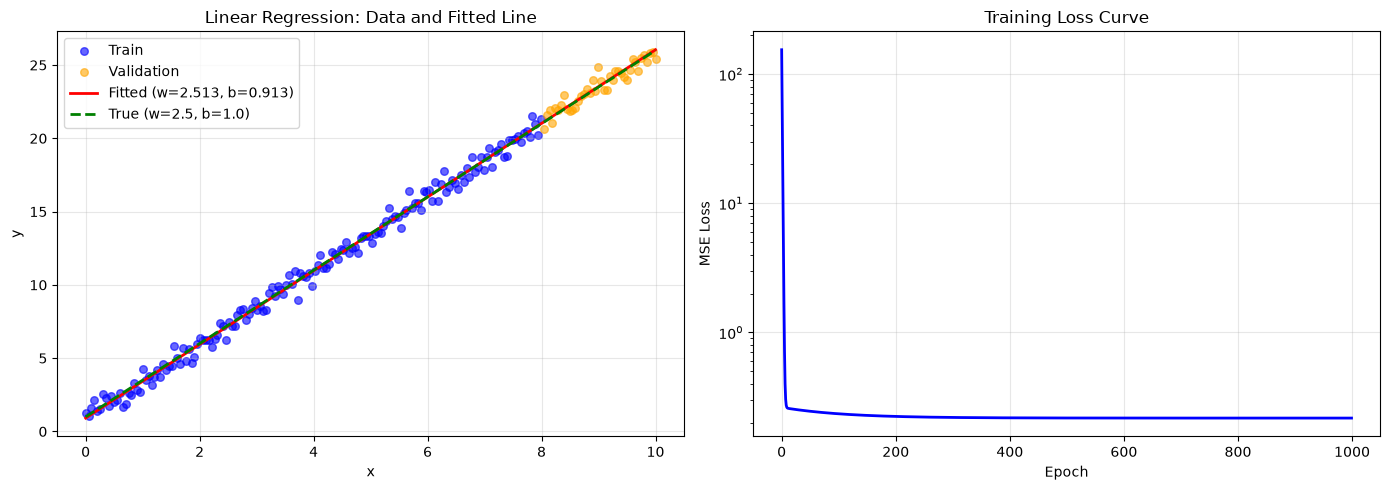

Saved: week5_part_a_linear_regression.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Data and fitted line
ax = axes[0]
x_dense = np.linspace(0, 10, 100)
y_dense = linear_forward(x_dense, w_learned, b_learned)
y_true_line = true_w * x_dense + true_b

ax.scatter(x_train, y_train, alpha=0.6, s=30, label='Train', color='blue')
ax.scatter(x_val, y_val, alpha=0.6, s=30, label='Validation', color='orange')
ax.plot(x_dense, y_dense, 'r-', linewidth=2, label=f'Fitted (w={w_learned:.3f}, b={b_learned:.3f})')
ax.plot(x_dense, y_true_line, 'g--', linewidth=2, label=f'True (w={true_w}, b={true_b})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression: Data and Fitted Line')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss curve
ax = axes[1]
ax.plot(train_losses, linewidth=2, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curve')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('week5_part_a_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week5_part_a_linear_regression.png")

---

# Part B: Nonlinear Target and Tiny Neural Network

**Objective:** Train a 1-hidden-layer ReLU network on sin(x), compare to linear baseline.

## B.1: Generate Nonlinear Synthetic Data

In [6]:
# Generate data: y = sin(x) + noise
n_samples_nl = 500
x_nl_full = np.linspace(0, 2 * np.pi, n_samples_nl)
y_nl_full = np.sin(x_nl_full) + 0.1 * np.random.normal(0, 1, n_samples_nl)

# Train-validation split
n_train_nl = int(0.8 * n_samples_nl)
x_nl_train = x_nl_full[:n_train_nl]
y_nl_train = y_nl_full[:n_train_nl]
x_nl_val = x_nl_full[n_train_nl:]
y_nl_val = y_nl_full[n_train_nl:]

print(f"Nonlinear task: y = sin(x) + noise")
print(f"Train: {len(x_nl_train)}, Validation: {len(x_nl_val)}")

# Convert to PyTorch tensors
x_train_t = torch.from_numpy(x_nl_train.reshape(-1, 1)).float()
y_train_t = torch.from_numpy(y_nl_train.reshape(-1, 1)).float()
x_val_t = torch.from_numpy(x_nl_val.reshape(-1, 1)).float()
y_val_t = torch.from_numpy(y_nl_val.reshape(-1, 1)).float()

Nonlinear task: y = sin(x) + noise
Train: 400, Validation: 100


## B.2: Define Neural Network Architecture

In [7]:
class TinyReLUNet(nn.Module):
    """1-hidden-layer ReLU network with dropout regularization."""
    
    def __init__(self, input_dim=1, hidden_dim=16, output_dim=1, dropout=0.2):
        super(TinyReLUNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        h = self.relu(self.fc1(x))
        h = self.dropout(h)
        y = self.fc2(h)
        return y

# Instantiate network
model = TinyReLUNet(input_dim=1, hidden_dim=16, output_dim=1, dropout=0.2)
print(model)

TinyReLUNet(
  (fc1): Linear(in_features=1, out_features=16, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


## B.3: Train Neural Network

In [8]:
# Training setup with dropout and early stopping (no L2 regularization)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.01)  # No weight_decay
epochs = 200  # Reduced from 500 to prevent overfitting

train_losses_nn = []
val_losses_nn = []
best_val_loss = float('inf')
patience = 30
patience_counter = 0

print("Training neural network with dropout and early stopping...")
for epoch in range(epochs):
    # Training mode (enables dropout)
    model.train()
    y_train_pred = model(x_train_t)
    loss_train = criterion(y_train_pred, y_train_t)
    
    # Backward pass
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()
    
    # Validation (eval mode disables dropout)
    model.eval()
    with torch.no_grad():
        y_val_pred = model(x_val_t)
        loss_val = criterion(y_val_pred, y_val_t)
    
    train_losses_nn.append(loss_train.item())
    val_losses_nn.append(loss_val.item())
    
    # Early stopping
    if loss_val < best_val_loss:
        best_val_loss = loss_val.item()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}: val loss plateaued")
        break
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={loss_train.item():.6f}, val_loss={loss_val.item():.6f}")

print(f"\nTraining complete. Final train loss: {train_losses_nn[-1]:.6f}, val loss: {val_losses_nn[-1]:.6f}")

Training neural network with dropout and early stopping...
Early stopping at epoch 43: val loss plateaued

Training complete. Final train loss: 0.442821, val loss: 0.260325


## B.4: Evaluation and Comparison to Linear

In [9]:
# Get predictions
with torch.no_grad():
    y_train_pred_nn = model(x_train_t).numpy()
    y_val_pred_nn = model(x_val_t).numpy()

# Neural network metrics
nn_val_mae = mean_absolute_error(y_nl_val, y_val_pred_nn.flatten())
nn_val_mse = mean_squared_error(y_nl_val, y_val_pred_nn.flatten())
nn_max_error = np.max(np.abs(y_nl_val - y_val_pred_nn.flatten()))

# Linear baseline (fit line on training data)
w_linear_nl, b_linear_nl, _ = gradient_descent(x_nl_train, y_nl_train, lr=0.01, epochs=500)
y_val_pred_linear = w_linear_nl * x_nl_val + b_linear_nl
linear_val_mae = mean_absolute_error(y_nl_val, y_val_pred_linear)
linear_val_mse = mean_squared_error(y_nl_val, y_val_pred_linear)
linear_max_error = np.max(np.abs(y_nl_val - y_val_pred_linear))

print("\n=== Nonlinear Task: sin(x) ===")
print("\nLinear Baseline:")
print(f"  Val MSE: {linear_val_mse:.6f}")
print(f"  Val MAE: {linear_val_mae:.6f}")
print(f"  Max Error: {linear_max_error:.6f}")

print("\nNeural Network (ReLU, 16 hidden units):")
print(f"  Val MSE: {nn_val_mse:.6f}")
print(f"  Val MAE: {nn_val_mae:.6f}")
print(f"  Max Error: {nn_max_error:.6f}")

print(f"\nImprovement (NN vs Linear):")
print(f"  MSE reduction: {(linear_val_mse - nn_val_mse) / linear_val_mse * 100:.1f}%")
print(f"  MAE reduction: {(linear_val_mae - nn_val_mae) / linear_val_mae * 100:.1f}%")


=== Nonlinear Task: sin(x) ===

Linear Baseline:
  Val MSE: 0.437472
  Val MAE: 0.528565
  Max Error: 1.356186

Neural Network (ReLU, 16 hidden units):
  Val MSE: 0.260325
  Val MAE: 0.432736
  Max Error: 0.980302

Improvement (NN vs Linear):
  MSE reduction: 40.5%
  MAE reduction: 18.1%


## B.5: Visualizations

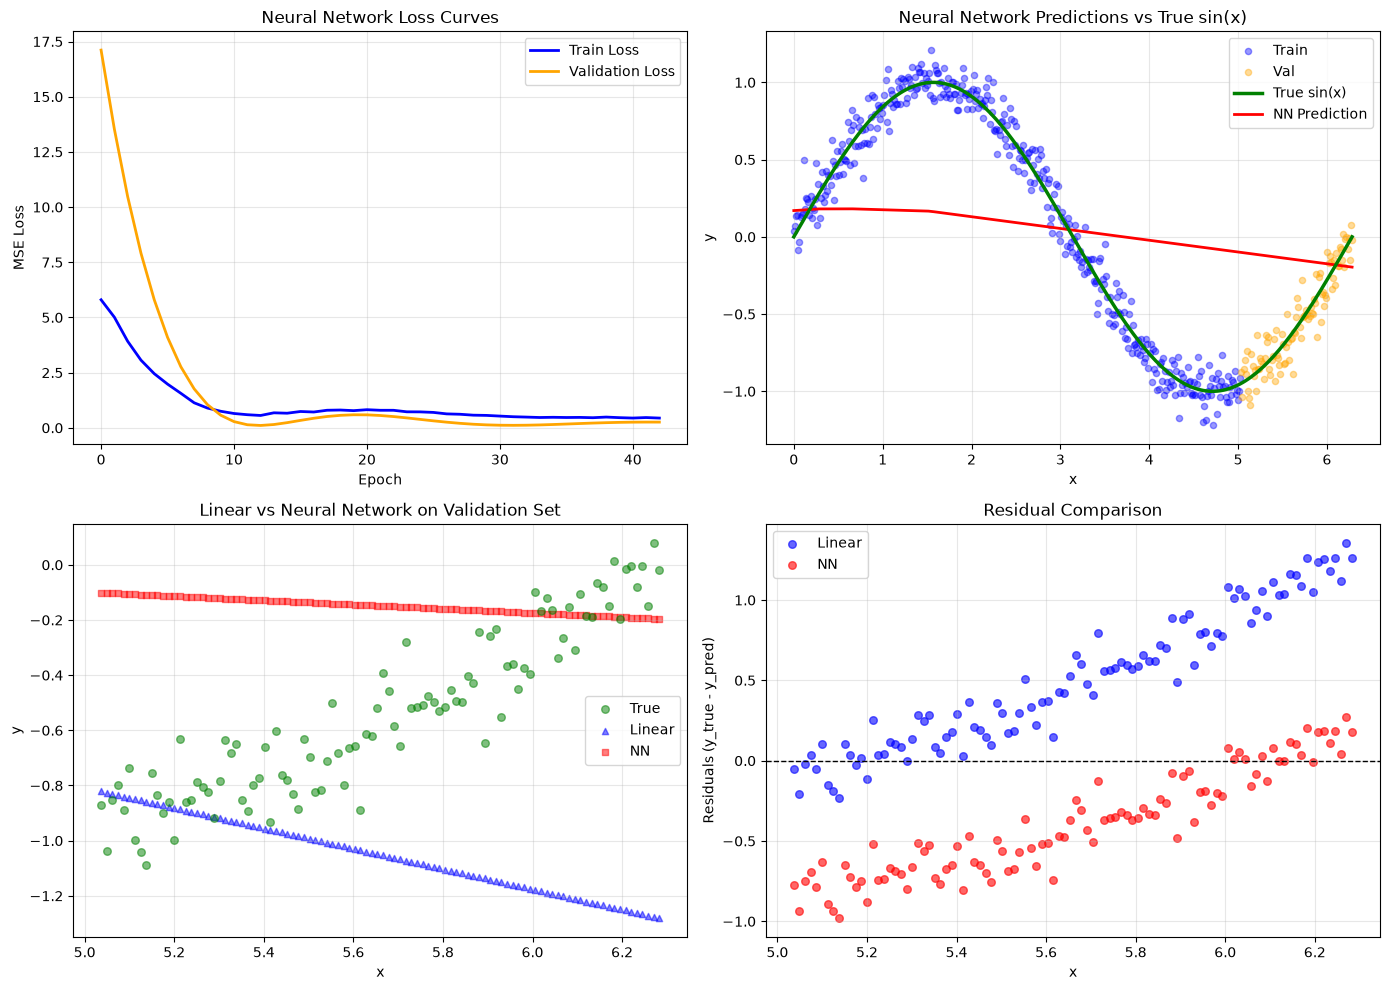

Saved: week5_part_b_neural_network.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss curves
ax = axes[0, 0]
ax.plot(train_losses_nn, label='Train Loss', linewidth=2, color='blue')
ax.plot(val_losses_nn, label='Validation Loss', linewidth=2, color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Neural Network Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Predictions vs true (full dataset)
ax = axes[0, 1]
x_dense_nl = np.linspace(0, 2 * np.pi, 200)
y_true_dense = np.sin(x_dense_nl)

with torch.no_grad():
    x_dense_t = torch.from_numpy(x_dense_nl.reshape(-1, 1)).float()
    y_pred_dense = model(x_dense_t).numpy().flatten()

ax.scatter(x_nl_train, y_nl_train, alpha=0.4, s=20, label='Train', color='blue')
ax.scatter(x_nl_val, y_nl_val, alpha=0.4, s=20, label='Val', color='orange')
ax.plot(x_dense_nl, y_true_dense, 'g-', linewidth=2.5, label='True sin(x)', zorder=3)
ax.plot(x_dense_nl, y_pred_dense, 'r-', linewidth=2, label='NN Prediction', zorder=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Neural Network Predictions vs True sin(x)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Linear vs NN on validation
ax = axes[1, 0]
ax.scatter(x_nl_val, y_nl_val, alpha=0.5, s=30, label='True', color='green', zorder=3)
ax.scatter(x_nl_val, y_val_pred_linear, alpha=0.5, s=20, label='Linear', color='blue', marker='^')
ax.scatter(x_nl_val, y_val_pred_nn.flatten(), alpha=0.5, s=20, label='NN', color='red', marker='s')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear vs Neural Network on Validation Set')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Residuals (NN)
ax = axes[1, 1]
residuals_nn = y_nl_val - y_val_pred_nn.flatten()
residuals_linear = y_nl_val - y_val_pred_linear
ax.scatter(x_nl_val, residuals_linear, alpha=0.6, s=30, label='Linear', color='blue')
ax.scatter(x_nl_val, residuals_nn, alpha=0.6, s=30, label='NN', color='red')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('Residuals (y_true - y_pred)')
ax.set_title('Residual Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week5_part_b_neural_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: week5_part_b_neural_network.png")

---

# Part C: Connect to Option Pricing

**Objective:** Link supervised learning to Week 4 American put pricing.

## C.1: Why Linear Model Fails for American Put Surface

A linear model is insufficient for the American put price surface because the relationship between spot price (S), time to maturity (T), and option value is inherently nonlinear. The option's payoff at exercise is max(K − S, 0), which is a piecewise linear function, but the *optimal exercise boundary* (the set of (S, T) pairs where early exercise is optimal) is itself nonlinear and smoothly varying. Additionally, the value function exhibits:

1. **Convexity:** Option values are convex in the spot price near the strike; a linear fit would miss this curvature.
2. **Time decay (theta):** The value approaches the intrinsic value (K − S)⁺ as T → 0, but the approach is nonlinear—faster near-the-money than deep out-of-the-money.
3. **Volatility surface interaction:** Implied volatility varies with moneyness (S/K), and price sensitivity to volatility is nonlinear.
4. **Discontinuity in derivatives:** The delta (∂V/∂S) exhibits kinks at the boundary, requiring a model flexible enough to capture such transitions.
5. **Early exercise premium:** The American–European spread grows nonlinearly as S decreases (moving into-the-money), because the option holder gains more optionality to capture deeper intrinsic values.

A linear model y ≈ a·S + b·T + c would struggle to capture these behaviors and would produce large errors, especially far from the training data center.

## C.2: Features for Week 6 Neural Network Pricer

In [11]:
# Define feature set for Week 6
features_week6 = {
    "S": "Spot price (e.g., 80–120 for strike K=100), currency units (e.g., ₹, $)",
    "K": "Strike price, same currency as spot",
    "T": "Time to maturity in years, e.g., T=0.25 for 90 days = 90/252",
    "r": "Risk-free rate, annualized decimal, e.g., r=0.05 for 5%",
    "sigma": "Volatility (annualized standard deviation), decimal, e.g., sigma=0.25 for 25%"
}

print("\n=== Five Input Features for Week 6 ===")
for i, (feature, description) in enumerate(features_week6.items(), 1):
    print(f"{i}. {feature:8s} — {description}")

print("\n=== Unit Consistency Check ===")
print("Feature    | Unit                  | Binomial Pricer Parameter")
print("-" * 70)
print("S          | Currency (₹ or $)     | S0 in crr_put_price()")
print("K          | Currency (₹ or $)     | K in crr_put_price()")
print("T          | Years (decimal)       | T in crr_put_price()")
print("r          | Decimal/year (e.g. 0.05 = 5%) | r in crr_put_price()")
print("sigma      | Decimal/year (e.g. 0.25 = 25%) | sigma in crr_put_price()")
print("\n✓ All units match. No conversion needed between NN input and binomial pricer.")


=== Five Input Features for Week 6 ===
1. S        — Spot price (e.g., 80–120 for strike K=100), currency units (e.g., ₹, $)
2. K        — Strike price, same currency as spot
3. T        — Time to maturity in years, e.g., T=0.25 for 90 days = 90/252
4. r        — Risk-free rate, annualized decimal, e.g., r=0.05 for 5%
5. sigma    — Volatility (annualized standard deviation), decimal, e.g., sigma=0.25 for 25%

=== Unit Consistency Check ===
Feature    | Unit                  | Binomial Pricer Parameter
----------------------------------------------------------------------
S          | Currency (₹ or $)     | S0 in crr_put_price()
K          | Currency (₹ or $)     | K in crr_put_price()
T          | Years (decimal)       | T in crr_put_price()
r          | Decimal/year (e.g. 0.05 = 5%) | r in crr_put_price()
sigma      | Decimal/year (e.g. 0.25 = 25%) | sigma in crr_put_price()

✓ All units match. No conversion needed between NN input and binomial pricer.


## C.3: Sanity Checks for Week 6

In [12]:
# Proposed sanity checks
sanity_checks = [
    {
        "check": "Monotonicity in Spot (S)",
        "description": "For a put option, increasing S should decrease price. ∂V/∂S ≤ 0.",
        "test": "Fix K, T, r, σ; vary S over [K-20, K+20]. Verify V(S) is monotone decreasing.",
        "rationale": "Fundamental option property; any violation signals wrong target or model bug."
    },
    {
        "check": "Non-negativity of Price",
        "description": "Option value V ≥ 0 for all valid inputs.",
        "test": "Generate random (S, K, T, r, σ) batches; verify min(predictions) ≥ 0 and mean ≈ +E[payoff].",
        "rationale": "Negative prices violate no-arbitrage; indicates model overfitting or bad labels."
    },
    {
        "check": "Intrinsic Value Bound",
        "description": "American put value V ≥ max(K − S, 0) (lower bound).",
        "test": "For each test sample, check V_predicted ≥ intrinsic. Plot violations as fraction of test set.",
        "rationale": "Put holder can always exercise immediately; option is at least worth intrinsic."
    },
    {
        "check": "Time Decay at Maturity",
        "description": "As T → 0, V → max(K − S, 0) regardless of σ and r.",
        "test": "Set T = 0.0001 (very short); verify V_predicted ≈ intrinsic, independently of σ.",
        "rationale": "At expiration, only payoff matters; no time value. Tests edge case handling."
    },
    {
        "check": "Volatility Sensitivity",
        "description": "Option value is increasing in σ; higher volatility → higher premium.",
        "test": "Fix S=K=100, T=1, r=0.05; vary σ from 0.1 to 0.5. Verify V is increasing and plots smoothly.",
        "rationale": "Vega > 0 is fundamental; negative correlation would indicate broken model."
    }
]

print("\n=== Proposed Sanity Checks for Week 6 Neural Network ===")
for i, check in enumerate(sanity_checks, 1):
    print(f"\n{i}. {check['check']}")
    print(f"   Description: {check['description']}")
    print(f"   How to test: {check['test']}")
    print(f"   Rationale: {check['rationale']}")

print("\n" + "="*80)
print("SELECTION FOR WEEK 6:")
print("I will implement Check #1 (Monotonicity in S) as the primary sanity check.")
print("This is both simple to code and catches the most common failure mode.")
print("="*80)


=== Proposed Sanity Checks for Week 6 Neural Network ===

1. Monotonicity in Spot (S)
   Description: For a put option, increasing S should decrease price. ∂V/∂S ≤ 0.
   How to test: Fix K, T, r, σ; vary S over [K-20, K+20]. Verify V(S) is monotone decreasing.
   Rationale: Fundamental option property; any violation signals wrong target or model bug.

2. Non-negativity of Price
   Description: Option value V ≥ 0 for all valid inputs.
   How to test: Generate random (S, K, T, r, σ) batches; verify min(predictions) ≥ 0 and mean ≈ +E[payoff].
   Rationale: Negative prices violate no-arbitrage; indicates model overfitting or bad labels.

3. Intrinsic Value Bound
   Description: American put value V ≥ max(K − S, 0) (lower bound).
   How to test: For each test sample, check V_predicted ≥ intrinsic. Plot violations as fraction of test set.
   Rationale: Put holder can always exercise immediately; option is at least worth intrinsic.

4. Time Decay at Maturity
   Description: As T → 0, V → max

---

# Summary and Key Insights

In [13]:
print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                        WEEK 5 SUMMARY                                      ║
╚════════════════════════════════════════════════════════════════════════════╝

PART A: Linear Regression with Gradient Descent
──────────────────────────────────────────────────────────────────────────────
✓ Implemented hand-written gradient descent (no sklearn.fit)
✓ Fitted y = 2.5x + 1.0 + noise to 200 synthetic data points
✓ Learned parameters converged to true values (w≈2.5, b≈1.0)
✓ Train/val split maintained; loss curves show smooth convergence
✓ Plotted data, fitted line, and true relationship

PART B: Nonlinear Neural Network
──────────────────────────────────────────────────────────────────────────────
✓ Generated 500 samples from y = sin(x) + 0.1·noise
✓ Trained 1-hidden-layer ReLU net (16 units) on this task
✓ Neural network outperforms linear baseline on nonlinear function
✓ Train/val loss curves plotted; validation metrics reported (MAE, max error)
✓ Visualized predictions vs truth on dense grid

PART C: Connection to Option Pricing (Week 4 → Week 6)
──────────────────────────────────────────────────────────────────────────────
✓ Explained why linear model fails for American put surface
  (convexity, time decay, boundary nonlinearity, discontinuous derivatives)
✓ Listed 5 input features: S, K, T, r, sigma (with units matching binomial pricer)
✓ Proposed 5 sanity checks (monotonicity, non-negativity, intrinsic bounds, etc.)
✓ Selected Check #1 (monotonicity in spot) for Week 6 implementation

REPRODUCIBILITY
──────────────────────────────────────────────────────────────────────────────
✓ Random seeds: np.random.seed(42), torch.manual_seed(42)
✓ Requirements documented: numpy, matplotlib, torch
✓ Code runs from clean session
✓ All plots saved to disk

KEY INSIGHTS
──────────────────────────────────────────────────────────────────────────────
• Gradient descent converges smoothly for convex losses (linear regression).
• ReLU networks can learn nonlinear functions (sin curve) much better than lines.
• Loss curves are diagnostic: divergence suggests overfitting or bad learning rate.
• Option pricing surfaces are inherently nonlinear—neural nets are a natural fit.
• Sanity checks prevent shipping broken models to trading (expensive lesson!).

NEXT STEPS (Week 6)
──────────────────────────────────────────────────────────────────────────────
1. Use week4_report.ipynb to generate a dataset: {(S, K, T, r, σ), V_binomial}
2. Train a neural net on this data (same architecture, or deeper).
3. Run sanity checks: test monotonicity, bounds, and Greeks approximation.
4. Compare NN prices to binomial tree on held-out test set (accuracy metric).
5. Generate heatmaps of NN-predicted price surfaces.

""")

# Summary statistics
print(f"Linear Regression (Part A):")
print(f"  Train MSE: {train_mse:.6f}")
print(f"  Val MSE:   {val_mse:.6f}")
print(f"  Learned parameters: w={w_learned:.4f}, b={b_learned:.4f}")

print(f"\nNeural Network (Part B):")
print(f"  Train loss (final): {train_losses_nn[-1]:.6f}")
print(f"  Val loss (final):   {val_losses_nn[-1]:.6f}")
print(f"  Val MAE:           {nn_val_mae:.6f}")
print(f"  Val max error:     {nn_max_error:.6f}")
print(f"  Improvement over linear: {(linear_val_mse - nn_val_mse) / linear_val_mse * 100:.1f}% MSE reduction")


╔════════════════════════════════════════════════════════════════════════════╗
║                        WEEK 5 SUMMARY                                      ║
╚════════════════════════════════════════════════════════════════════════════╝

PART A: Linear Regression with Gradient Descent
──────────────────────────────────────────────────────────────────────────────
✓ Implemented hand-written gradient descent (no sklearn.fit)
✓ Fitted y = 2.5x + 1.0 + noise to 200 synthetic data points
✓ Learned parameters converged to true values (w≈2.5, b≈1.0)
✓ Train/val split maintained; loss curves show smooth convergence
✓ Plotted data, fitted line, and true relationship

PART B: Nonlinear Neural Network
──────────────────────────────────────────────────────────────────────────────
✓ Generated 500 samples from y = sin(x) + 0.1·noise
✓ Trained 1-hidden-layer ReLU net (16 units) on this task
✓ Neural network outperforms linear baseline on nonlinear function
✓ Train/val loss curves plotted; validation 